# EDA

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns


In [2]:
df = pd.read_csv('../data/MultiClassData.csv')


In [3]:
print(df.describe())


                pH          TDS    Turbidity     Phospate      Nitrate  \
count  5100.000000  5100.000000  5100.000000  5100.000000  5100.000000   
mean      7.550281   800.107843     2.161506     0.015124     7.019804   
std       0.029787   103.784643     1.184488     0.008739     0.813569   
min       7.400000   622.000000     0.100000     0.000003     6.000000   
25%       7.525445   711.000000     1.130000     0.007376     6.000000   
50%       7.550255   799.000000     2.145000     0.015224     7.000000   
75%       7.575749   891.000000     3.210000     0.022717     8.000000   
max       7.600000   979.000000     4.200000     0.029997     8.000000   

              Iron    COD(mg/L)     Chlorine       Sodium        Class  
count  5100.000000  5100.000000  5100.000000  5100.000000  5100.000000  
mean      0.354148   409.757059     2.511569    10.538627     2.983529  
std       0.031684    11.777568     1.129601     5.802080     0.676652  
min       0.300028   390.000000     1.000

In [4]:
df.head(10)


,pH,TDS,Turbidity,Phospate,Nitrate,Iron,COD(mg/L),Chlorine,Sodium,Class
0,7.6,756,2.42,0.013580,8,0.408453,398,3,2,0
1,7.6,897,1.33,0.014005,8,0.309561,392,1,13,4
2,7.5,951,2.29,0.016966,7,0.317214,418,1,15,3
3,7.6,767,2.00,0.018072,7,0.317923,415,4,4,3
4,7.6,921,2.03,0.012102,8,0.347554,404,2,12,3
5,7.6,835,1.35,0.007798,6,0.384176,392,4,19,4
6,7.5,976,2.21,0.017084,6,0.353537,427,1,15,3
7,7.6,724,0.23,0.001214,8,0.390924,407,4,6,3
8,7.6,714,1.52,0.001791,8,0.300498,419,3,9,3
9,7.5,837,0.53,0.026122,8,0.405122,397,2,13,0


---

## Class Vs pH

<Axes: title={'center': 'Class Distribution'}, xlabel='Class'>

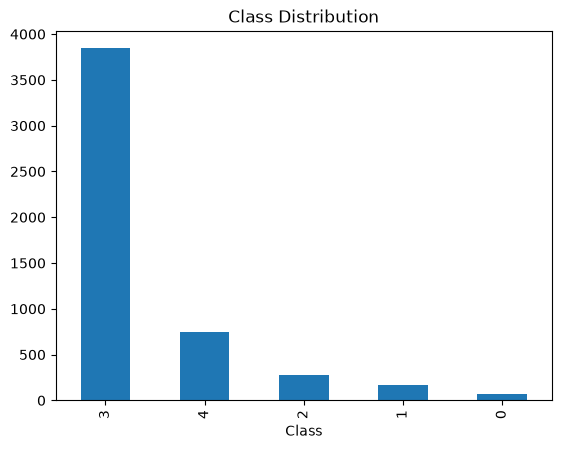

In [5]:
df['Class'].value_counts().plot(kind='bar', title='Class Distribution')


### pH variation across classes

In [6]:
print(df.groupby('Class')['pH'].describe())


        count      mean       std  min       25%       50%       75%  max
Class                                                                    
0        72.0  7.546442  0.030174  7.5  7.520952  7.547477  7.569841  7.6
1       168.0  7.548118  0.029741  7.5  7.520513  7.548312  7.574455  7.6
2       274.0  7.549829  0.030394  7.4  7.524652  7.549449  7.575832  7.6
3      3844.0  7.550187  0.029735  7.4  7.525445  7.550217  7.575195  7.6
4       742.0  7.551793  0.029798  7.5  7.526741  7.551431  7.577908  7.6


<Axes: title={'center': 'pH'}, xlabel='Class'>

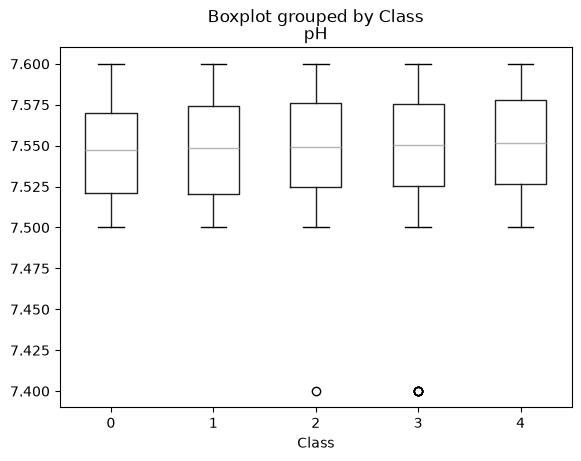

In [7]:
# PH variation across classes
df.boxplot(column ='pH',by='Class',grid=False)


### Mean pH by Class

<Axes: title={'center': 'Mean pH by Class'}, xlabel='Class'>

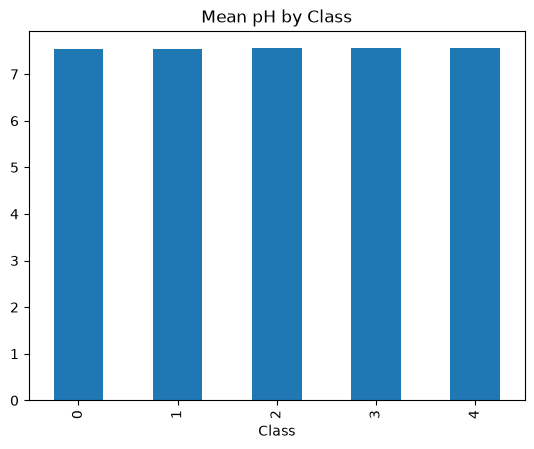

In [8]:
df.groupby('Class')['pH'].mean().plot(kind='bar',title='Mean pH by Class')


## turbidity vs pH

### Turbidity Variation across Classes

<Axes: title={'center': 'Turbidity'}, xlabel='Class'>

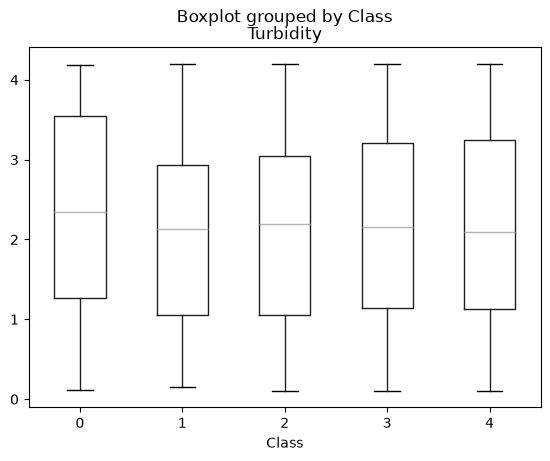

In [9]:
df.boxplot(column = 'Turbidity',by='Class',grid=False)


### Mean Turbidity across classes

<Axes: title={'center': 'mean turbidity by class'}, xlabel='Class', ylabel='Turbudity'>

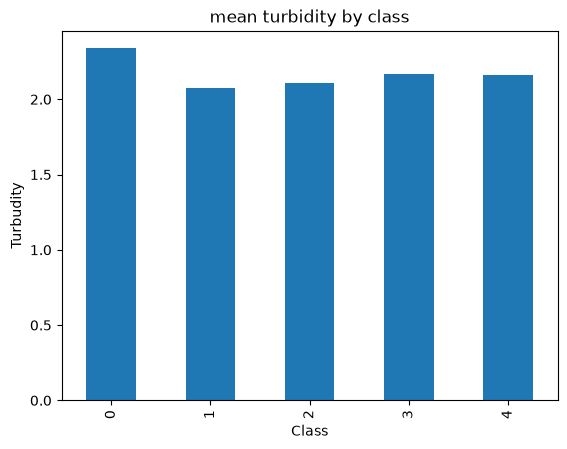

In [10]:
df.groupby('Class')['Turbidity'].mean().plot(kind='bar',title='mean turbidity by class',ylabel ='Turbudity')


----

## Finding Stastical Meaning and describing classes

In [11]:
features = df.drop(columns=['Class']).columns

for col in features:
    print(f'\n {col}')
    print(df.groupby('Class')[col].describe()[['mean','std','25%','50%','75%']])



 pH
           mean       std       25%       50%       75%
Class                                                  
0      7.546442  0.030174  7.520952  7.547477  7.569841
1      7.548118  0.029741  7.520513  7.548312  7.574455
2      7.549829  0.030394  7.524652  7.549449  7.575832
3      7.550187  0.029735  7.525445  7.550217  7.575195
4      7.551793  0.029798  7.526741  7.551431  7.577908

 TDS
             mean         std     25%    50%     75%
Class                                               
0      769.513889   82.033486  715.00  773.0  849.75
1      762.994048   82.354898  694.75  768.5  834.50
2      939.722628   22.436473  920.25  941.0  958.00
3      799.501821  103.991246  709.00  798.0  891.00
4      763.063342   81.786002  695.00  764.0  831.00

 Turbidity
           mean       std     25%    50%     75%
Class                                           
0      2.338056  1.236184  1.2625  2.340  3.5475
1      2.072738  1.148075  1.0525  2.135  2.9325
2      2.108066  1

In [12]:
print(df.groupby('Class')['TDS'].describe())


        count        mean         std    min     25%    50%     75%    max
Class                                                                     
0        72.0  769.513889   82.033486  623.0  715.00  773.0  849.75  897.0
1       168.0  762.994048   82.354898  622.0  694.75  768.5  834.50  899.0
2       274.0  939.722628   22.436473  900.0  920.25  941.0  958.00  979.0
3      3844.0  799.501821  103.991246  622.0  709.00  798.0  891.00  979.0
4       742.0  763.063342   81.786002  622.0  695.00  764.0  831.00  899.0


----

## getting to know classes

-- from describe we came to know that <br>
-- COD TDS Phosphate and Iron dominates the variation excpet the rest <br>
-- we will use k means to discover the classese !! <br>

### K means only pH

In [13]:
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

def km_ari(X,y,n_clusters):
    kmeans = KMeans(n_clusters=n_clusters,random_state=42,n_init=20)
    cluster = kmeans.fit_predict(X)
    ari = adjusted_rand_score(y, cluster)
    return cluster, ari


In [14]:
X = df[['TDS']]
y = df['Class']

cluster_tds,ari = km_ari(X,y,5)


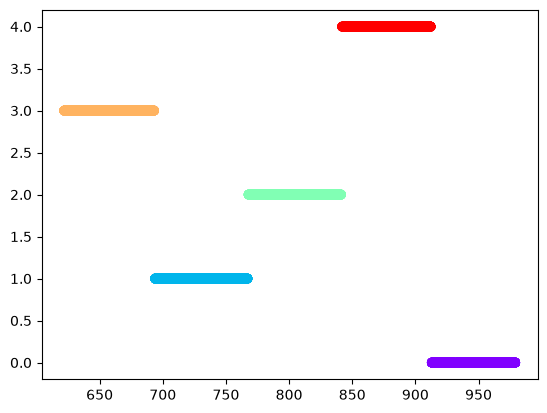

In [15]:
plt.scatter(x=df['TDS'], y=cluster_tds, c=cluster_tds, cmap='rainbow')


In [16]:
features = ['TDS','pH','COD(mg/L)','Phospate','Iron']
clusters = {}
ari = {}
for f in features:
    X = df[[f]]
    clusters[f],ari[f] = km_ari(X,y,5)
    print(f'ari_{f}={ari[f]}')


ari_TDS=0.00965649192126315
ari_pH=-0.00019020223353259552
ari_COD(mg/L)=0.15672424407898544
ari_Phospate=0.004677371164145492
ari_Iron=0.0012903951842918172


In [17]:
from sklearn.preprocessing import StandardScaler

X = df[features]
scaler_partial = StandardScaler()
X_scaled_partial= scaler_partial.fit_transform(X)

partial_features_cluster, ari_partial_features = km_ari(X_scaled_partial,y,5)
# features = ['TDS','pH','COD(mg/L)','Phospate','Iron']
print(f'partial_features_ari = {ari_partial_features}')


partial_features_ari = 0.0064016337353406064


In [18]:
# partial features without pH

X_without_ph = df[[f for f in features if f!='pH']]
scaler_without_ph = StandardScaler()
X_scaled_without_ph = scaler_without_ph.fit_transform(X_without_ph)
partial_features_without_ph_cluster,ari_partial_features_without_ph = km_ari(X_scaled_without_ph,y,5)
print(f'partial features without ph = {ari_partial_features_without_ph}')


partial features without ph = 0.03677866262267638


In [19]:
X = df.drop(columns=['Class'])
scaler_features_all = StandardScaler()
X_scaled_features_all = scaler_features_all.fit_transform(X)
all_cluster,ari_all = km_ari(X_scaled_features_all,y,5)
print(f'ari for all features = {ari_all}')


ari for all features = 0.03579099004465905


In [20]:
X_all_no_pH = df.drop(columns=['Class','pH'])
scaler_features_all_no_ph = StandardScaler()
X_scaled_features_all_no_ph = scaler_features_all_no_ph.fit_transform(X_all_no_pH)
all_cluster_no_ph,ari_all_no_ph = km_ari(X_scaled_features_all_no_ph,y,5)
print(f'ari for all features no ph = {ari_all_no_ph}')


ari for all features no ph = 0.04521003268048248


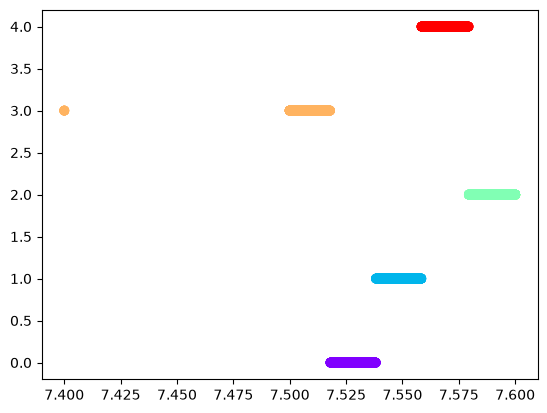

In [21]:
X = df[['pH']]
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init =10
)

df['Cluster_pH']=kmeans.fit_predict(X)
plt.scatter(x=df['pH'], y=df['Cluster_pH'], c=df['Cluster_pH'], cmap='rainbow')


In [22]:
pd.crosstab(df['Class'],df['Cluster_pH'],rownames=['Class'],colnames=['Cluster_pH'],normalize='index')


Cluster_pH,0,1,2,3,4
Class,,,,,
0,0.194444,0.194444,0.208333,0.236111,0.166667
1,0.208333,0.184524,0.184524,0.202381,0.220238
2,0.226277,0.189781,0.218978,0.156934,0.208029
3,0.197971,0.208377,0.215921,0.178460,0.199272
4,0.196765,0.190027,0.241240,0.171159,0.200809


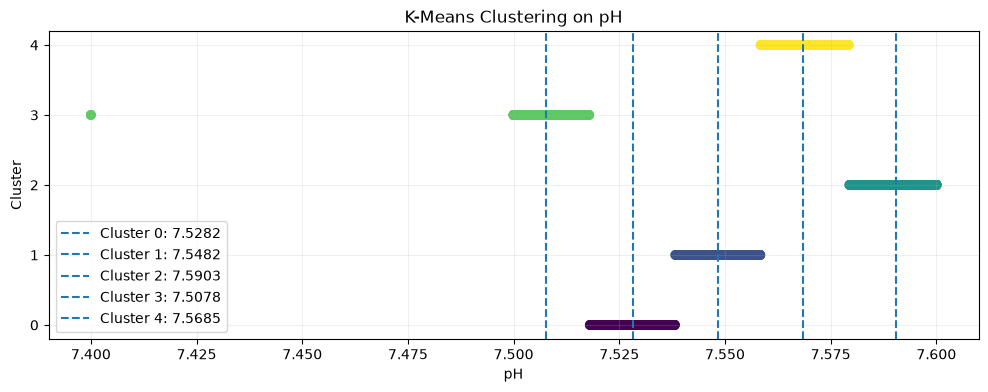

In [23]:
centers = kmeans.cluster_centers_.flatten()

plt.figure(figsize=(12, 4))

plt.scatter(
    df['pH'],
    df['Cluster_pH'],
    c=df['Cluster_pH'],
    alpha=0.5
)

for i, center in enumerate(centers):
    plt.axvline(
        center,
        linestyle='--',
        label=f'Cluster {i}: {center:.4f}'
    )

plt.xlabel('pH')
plt.ylabel('Cluster')
plt.title('K-Means Clustering on pH')
plt.yticks(range(5))
plt.legend()
plt.grid(alpha=0.2)

plt.show()


In [24]:
ari = adjusted_rand_score(
    df['Class'],
    df['Cluster_pH']
)

print("ARI:", ari)


ARI: -0.00019020223353259552


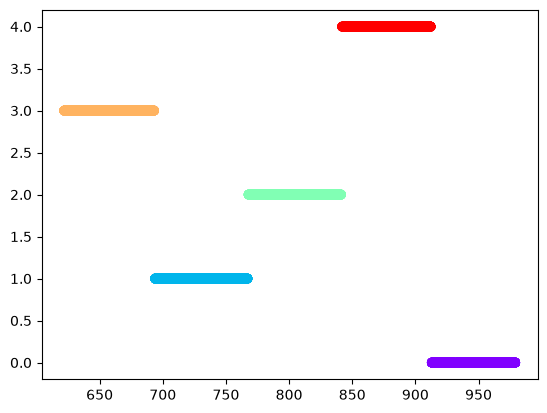

In [25]:
X = df[['TDS']]

df['Cluster_TDS']=kmeans.fit_predict(X)
plt.scatter(x=df['TDS'], y=df['Cluster_TDS'], c=df['Cluster_TDS'], cmap='rainbow')


- ---

## CV matrix pattern finding for classes 

In [3]:
features = [x for x in df.columns if x != 'Class']


In [4]:
for x in range(len(features)):
    df[features[x]+'_mean'] = df.groupby('Class')[features[x]].transform('mean')

for x in range(len(features)):
    df[features[x]+'_mean'] = df.groupby('Class')[features[x]].transform('std')
    

In [5]:
feature_means= {}

for x in range(len(features)):
    features_mean = df[features[x]].mean()
    feature_means[features[x]+'_mean'] = features_mean
   
    
feature_stds={}
for x in range(len(features)):
    features_std = df[features[x]].std()
    feature_stds[features[x]+'_std'] = features_std
    


    


In [6]:
class_0 = {}
class_1 = {}
class_2 = {}
class_3 = {}
class_4 = {}

for i in range(len(features)):
    feature = features[i]
    class_0[feature+'_mean'] = df[df['Class']==0][feature].mean()
    class_1[feature+'_mean'] = df[df['Class']==1][feature].mean()
    class_2[feature+'_mean'] = df[df['Class']==2][feature].mean()
    class_3[feature+'_mean'] = df[df['Class']==3][feature].mean()
    class_4[feature+'_mean'] = df[df['Class']==4][feature].mean()
    

for i in range(len(features)):
    feature = features[i]
    class_0[feature+'_std'] = df[df['Class']==0][feature].std()
    class_1[feature+'_std'] = df[df['Class']==1][feature].std()
    class_2[feature+'_std'] = df[df['Class']==2][feature].std()
    class_3[feature+'_std'] = df[df['Class']==3][feature].std()
    class_4[feature+'_std'] = df[df['Class']==4][feature].std()
    


In [7]:
classes = [0,1,2,3,4]

class_dict = {
    0: class_0,
    1: class_1,
    2: class_2,
    3: class_3,
    4: class_4
}



class_mean_diffs = {}
class_std_diffs = {}

# For each class,calculate the difference between the class mean and overall mean for each feature
for c in classes:
    class_mean_diffs[c]={}
    for f in features:
        class_mean = class_dict[c][f + '_mean']
        overall_mean = feature_means[f +'_mean']  
        difference = class_mean - overall_mean
        class_mean_diffs[c][f+'_mean'] = difference     
# For each class,calculate the difference between the class std and overall std for each feature

for c in classes:
    class_std_diffs[c] = {}
    for f in features:
        class_std = class_dict[c][f + '_std']
        overall_std = feature_stds[f+'_std']
        difference = class_std - overall_std
        class_std_diffs[c][f+'_std'] = difference


<Axes: >

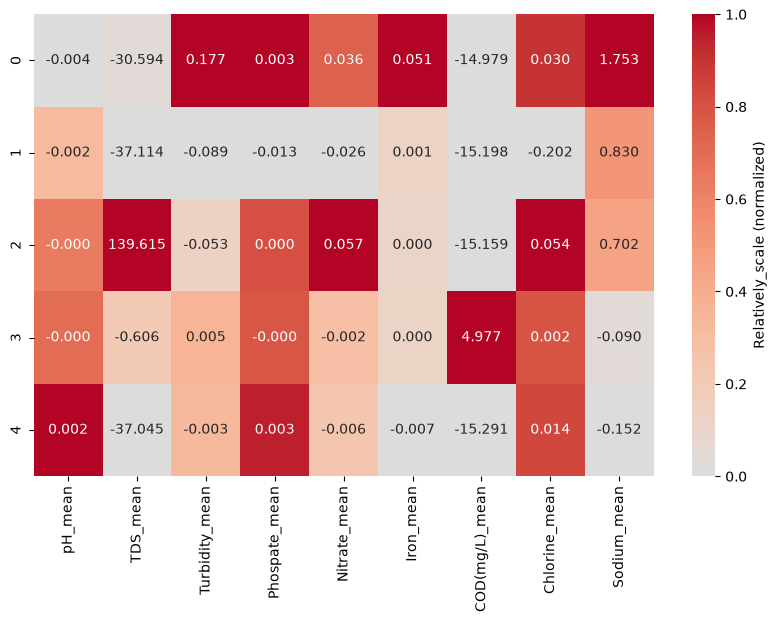

In [8]:
mean_df = pd.DataFrame.from_dict(class_mean_diffs,orient='index')
scale = MinMaxScaler()

mean_df_normalized = mean_df.copy()
feature =mean_df_normalized.columns.tolist()
mean_df_normalized[feature] = scale.fit_transform(mean_df_normalized[feature])

plt.figure(figsize = (10,6))
sns.heatmap(mean_df_normalized,annot = mean_df,fmt = '.3f',cmap ='coolwarm',center =0,cbar_kws={'label':'Relatively_scale (normalized)'})



<Axes: >

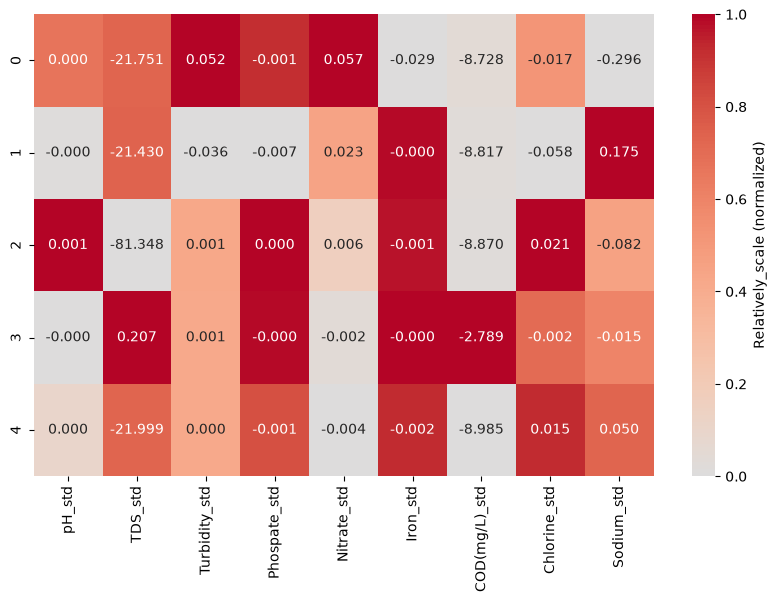

In [9]:
std_df =pd.DataFrame.from_dict(class_std_diffs,orient='index')
scaler = MinMaxScaler()
std_df_normalized = std_df.copy()
feature =std_df_normalized.columns.tolist()
std_df_normalized[feature] = scaler.fit_transform(std_df_normalized[feature])
plt.figure(figsize = (10,6))
sns.heatmap(std_df_normalized,annot = std_df,fmt = '.3f',cmap ='coolwarm',center =0,cbar_kws={'label':'Relatively_scale (normalized)'})


In [10]:

coeff_of_variation = {}
for c in classes:
    coeff_of_variation[c] = {}
    for f in features:
        std = class_std_diffs[c][f + '_std']
        mean = class_mean_diffs[c][f + '_mean']
        cv = std / mean if mean != 0 else 0        
        coeff_of_variation[c][f + '_cv'] = cv
        
        
        
        

<Axes: >

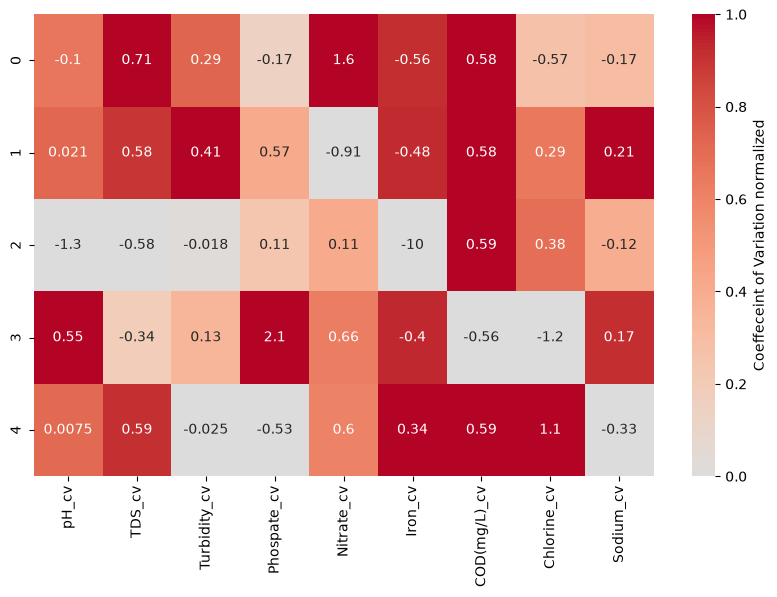

In [11]:
coeff_of_variation_df = pd.DataFrame.from_dict(coeff_of_variation,orient='index')
scaler = MinMaxScaler()
cv_df_normalized = coeff_of_variation_df.copy()
feature = cv_df_normalized.columns.to_list()
cv_df_normalized[feature] = scaler.fit_transform(cv_df_normalized[feature]) 
plt.figure(figsize=(10, 6))
sns.heatmap(cv_df_normalized,annot=coeff_of_variation_df,cmap="coolwarm",center=0,cbar_kws={'label' : 'Coeffeceint of Variation normalized'})


In [12]:
print(coeff_of_variation_df)


      pH_cv    TDS_cv  Turbidity_cv  Phospate_cv  Nitrate_cv    Iron_cv  \
0 -0.100817  0.710963      0.292812    -0.169402    1.586993  -0.563524   
1  0.021177  0.577406      0.410213     0.572562   -0.909585  -0.476458   
2 -1.346229 -0.582662     -0.017634     0.114443    0.106280 -10.332518   
3  0.550310 -0.340917      0.125312     2.145526    0.662655  -0.403073   
4  0.007518  0.593844     -0.025188    -0.533857    0.604247   0.344121   

   COD(mg/L)_cv  Chlorine_cv  Sodium_cv  
0      0.582648    -0.567885  -0.168577  
1      0.580183     0.285215   0.211318  
2      0.585153     0.384977  -0.116891  
3     -0.560486    -1.176678   0.166967  
4      0.587578     1.077807  -0.330129  


In [13]:
coeff_of_variation


{0: {'pH_cv': np.float64(-0.10081678055582702),
  'TDS_cv': np.float64(0.7109626076853541),
  'Turbidity_cv': np.float64(0.2928118808432763),
  'Phospate_cv': np.float64(-0.16940209871355574),
  'Nitrate_cv': np.float64(1.5869929357863763),
  'Iron_cv': np.float64(-0.5635244638873448),
  'COD(mg/L)_cv': np.float64(0.582647776319022),
  'Chlorine_cv': np.float64(-0.5678851501353551),
  'Sodium_cv': np.float64(-0.16857664318646431)},
 1: {'pH_cv': np.float64(0.021177139225569904),
  'TDS_cv': np.float64(0.5774064418692417),
  'Turbidity_cv': np.float64(0.4102133263895299),
  'Phospate_cv': np.float64(0.5725621069975371),
  'Nitrate_cv': np.float64(-0.9095852248388674),
  'Iron_cv': np.float64(-0.4764580229940759),
  'COD(mg/L)_cv': np.float64(0.5801827997967093),
  'Chlorine_cv': np.float64(0.2852148037898018),
  'Sodium_cv': np.float64(0.21131797097155242)},
 2: {'pH_cv': np.float64(-1.346229275126002),
  'TDS_cv': np.float64(-0.5826615753584087),
  'Turbidity_cv': np.float64(-0.0176337

In [14]:
columns = coeff_of_variation_df.columns.to_list()
class_0_df = pd.DataFrame(coeff_of_variation[0],columns= columns,index=[0])
class_0_df = class_0_df.transpose()
class_0_df.sort_values(by=0,ascending=True,inplace =True)
class_0_df


,0
Chlorine_cv,-0.567885
Iron_cv,-0.563524
Phospate_cv,-0.169402
Sodium_cv,-0.168577
pH_cv,-0.100817
Turbidity_cv,0.292812
COD(mg/L)_cv,0.582648
TDS_cv,0.710963
Nitrate_cv,1.586993


In [15]:
class_dfs = {
    c: pd.DataFrame(
        values,
        columns=columns,
        index=[c]
    ).T
    for c, values in coeff_of_variation.items()
}


In [16]:
print(
"\n ==================================================\n",
class_dfs[0].sort_values(by = 0,ascending =True),
"\n ==================================================\n",
class_dfs[1].sort_values(by = 1,ascending =True),
"\n ==================================================\n",
class_dfs[2].sort_values(by = 2,ascending =True),
"\n ==================================================\n",
class_dfs[3].sort_values(by = 3,ascending =True),
"\n ==================================================\n",
class_dfs[4].sort_values(by = 4,ascending =True),
"\n ==================================================\n")



                      0
Chlorine_cv  -0.567885
Iron_cv      -0.563524
Phospate_cv  -0.169402
Sodium_cv    -0.168577
pH_cv        -0.100817
Turbidity_cv  0.292812
COD(mg/L)_cv  0.582648
TDS_cv        0.710963
Nitrate_cv    1.586993 
                      1
Nitrate_cv   -0.909585
Iron_cv      -0.476458
pH_cv         0.021177
Sodium_cv     0.211318
Chlorine_cv   0.285215
Turbidity_cv  0.410213
Phospate_cv   0.572562
TDS_cv        0.577406
COD(mg/L)_cv  0.580183 
                       2
Iron_cv      -10.332518
pH_cv         -1.346229
TDS_cv        -0.582662
Sodium_cv     -0.116891
Turbidity_cv  -0.017634
Nitrate_cv     0.106280
Phospate_cv    0.114443
Chlorine_cv    0.384977
COD(mg/L)_cv   0.585153 
                      3
Chlorine_cv  -1.176678
COD(mg/L)_cv -0.560486
Iron_cv      -0.403073
TDS_cv       -0.340917
Turbidity_cv  0.125312
Sodium_cv     0.166967
pH_cv         0.550310
Nitrate_cv    0.662655
Phospate_cv   2.145526 
                      4
Phospate_cv  -0.533857
Sodium_cv    -

In [17]:
class_std_diffs


{0: {'pH_std': np.float64(0.0003870130997720711),
  'TDS_std': np.float64(-21.751157491824713),
  'Turbidity_std': np.float64(0.05169584187272336),
  'Phospate_std': np.float64(-0.000571039931809127),
  'Nitrate_std': np.float64(0.056737590580075103),
  'Iron_std': np.float64(-0.028905445307218162),
  'COD(mg/L)_std': np.float64(-8.727644792164863),
  'Chlorine_std': np.float64(-0.017092229518779645),
  'Sodium_std': np.float64(-0.2955214663546242)},
 1: {'pH_std': np.float64(-4.579162680536791e-05),
  'TDS_std': np.float64(-21.429744614430703),
  'Turbidity_std': np.float64(-0.03641372922861863),
  'Phospate_std': np.float64(-0.007231034292827412),
  'Nitrate_std': np.float64(0.023427552219589476),
  'Iron_std': np.float64(-0.0004923313573535239),
  'COD(mg/L)_std': np.float64(-8.817348414434296),
  'Chlorine_std': np.float64(-0.05762617310184437),
  'Sodium_std': np.float64(0.17548270496982177)},
 2: {'pH_std': np.float64(0.0006073615714158077),
  'TDS_std': np.float64(-81.3481703383

In [18]:
features


['pH',
 'TDS',
 'Turbidity',
 'Phospate',
 'Nitrate',
 'Iron',
 'COD(mg/L)',
 'Chlorine',
 'Sodium']

In [19]:
columns = coeff_of_variation_df.columns.tolist()

class_df = {}

for c in range(len(coeff_of_variation)):
    cv_values = pd.Series(
        coeff_of_variation[c],
        index=columns
    )

    class_df[c] = pd.DataFrame({
        "mean": [
            class_mean_diffs[c][f + "_mean"]
            for f in features
        ],
        "std": [
            class_std_diffs[c][f + "_std"]
            for f in features
        ],
        "cv": [
            cv_values[f + "_cv"]
            for f in features
        ]
    }, index=features)



In [20]:
class_df


{0:                 mean        std        cv
 pH         -0.003839   0.000387 -0.100817
 TDS       -30.593954 -21.751157  0.710963
 Turbidity   0.176550   0.051696  0.292812
 Phospate    0.003371  -0.000571 -0.169402
 Nitrate     0.035752   0.056738  1.586993
 Iron        0.051294  -0.028905 -0.563524
 COD(mg/L) -14.979281  -8.727645  0.582648
 Chlorine    0.030098  -0.017092 -0.567885
 Sodium      1.753039  -0.295521 -0.168577,
 1:                 mean        std        cv
 pH         -0.002162  -0.000046  0.021177
 TDS       -37.113796 -21.429745  0.577406
 Turbidity  -0.088768  -0.036414  0.410213
 Phospate   -0.012629  -0.007231  0.572562
 Nitrate    -0.025756   0.023428 -0.909585
 Iron        0.001033  -0.000492 -0.476458
 COD(mg/L) -15.197535  -8.817348  0.580183
 Chlorine   -0.202045  -0.057626  0.285215
 Sodium      0.830420   0.175483  0.211318,
 2:                  mean        std         cv
 pH          -0.000451   0.000607  -1.346229
 TDS        139.614785 -81.348170  -0.5

In [21]:
print(
"\n ==================================================\n",
"Class 0: \n",
class_df[0],
"\n ==================================================\n",
"Class 1: \n",
class_df[1],
"\n ==================================================\n",
"Class 2: \n",
class_df[2],
"\n ==================================================\n",
"Class 3: \n",
class_df[3],
"\n ==================================================\n",
"Class 4: \n",
class_df[4],
"\n ==================================================\n")



 Class 0: 
                 mean        std        cv
pH         -0.003839   0.000387 -0.100817
TDS       -30.593954 -21.751157  0.710963
Turbidity   0.176550   0.051696  0.292812
Phospate    0.003371  -0.000571 -0.169402
Nitrate     0.035752   0.056738  1.586993
Iron        0.051294  -0.028905 -0.563524
COD(mg/L) -14.979281  -8.727645  0.582648
Chlorine    0.030098  -0.017092 -0.567885
Sodium      1.753039  -0.295521 -0.168577 
 Class 1: 
                 mean        std        cv
pH         -0.002162  -0.000046  0.021177
TDS       -37.113796 -21.429745  0.577406
Turbidity  -0.088768  -0.036414  0.410213
Phospate   -0.012629  -0.007231  0.572562
Nitrate    -0.025756   0.023428 -0.909585
Iron        0.001033  -0.000492 -0.476458
COD(mg/L) -15.197535  -8.817348  0.580183
Chlorine   -0.202045  -0.057626  0.285215
Sodium      0.830420   0.175483  0.211318 
 Class 2: 
                  mean        std         cv
pH          -0.000451   0.000607  -1.346229
TDS        139.614785 -81.348170 

- ---

## pattern finding deep dive

In [22]:
tds_by_class = [
    df[df["Class"] == c]["TDS"]
    for c in range(5)
]

ph_by_class = [
    df[df["Class"]==c]['pH']
    for c in range(5)
]

turbidity_by_class = [
    df[df["Class"]==c]['Turbidity']
    for c in range(5)
]

phospate_by_class = [
    df[df["Class"]==c]['Phospate']
    for c in range(5)
]

nitrate_by_class = [
    df[df["Class"]==c]['Nitrate']
    for c in range(5)
]

iron_by_class = [
    df[df["Class"]==c]['Iron']
    for c in range(5)
]

cod_by_class = [
    df[df["Class"]==c]['COD(mg/L)']
    for c in range(5)
]

chlorine_by_class = [
    df[df["Class"]==c]['Chlorine']
    for c in range(5)
]

sodium_by_class = [
    df[df["Class"]==c]['Sodium']
    for c in range(5)
]


In [23]:
tds_summary =pd.DataFrame({
    "count" : [x.count() for x in tds_by_class],
    "mean" : [x.mean() for x in tds_by_class],
    "std" : [x.std() for x in tds_by_class],
    "q1" : [x.quantile(0.25) for x in tds_by_class],
    "q2" : [x.quantile(0.75) for x in tds_by_class]
}, index = range (5))
tds_summary.index.name = "Class"
ph_summary =pd.DataFrame({
    "count" : [x.count() for x in ph_by_class],
    "mean" : [x.mean() for x in ph_by_class],
    "std" : [x.std() for x in ph_by_class],
    "q1" : [x.quantile(0.25) for x in ph_by_class],
    "q2" : [x.quantile(0.75) for x in ph_by_class]
}, index = range (5))
ph_summary.index.name = "Class"
turbidity_summary =pd.DataFrame({
    "count" : [x.count() for x in turbidity_by_class],
    "mean" : [x.mean() for x in turbidity_by_class],
    "std" : [x.std() for x in turbidity_by_class],
    "q1" : [x.quantile(0.25) for x in turbidity_by_class],
    "q2" : [x.quantile(0.75) for x in turbidity_by_class]
}, index = range (5))
turbidity_summary.index.name = "Class"
phospate_summary =pd.DataFrame({
    "count" : [x.count() for x in phospate_by_class],
    "mean" : [x.mean() for x in phospate_by_class],
    "std" : [x.std() for x in phospate_by_class],
    "q1" : [x.quantile(0.25) for x in phospate_by_class],
    "q2" : [x.quantile(0.75) for x in phospate_by_class]
}, index = range (5))
phospate_summary.index.name = "Class"
nitrate_summary =pd.DataFrame({
    "count" : [x.count() for x in nitrate_by_class],
    "mean" : [x.mean() for x in nitrate_by_class],
    "std" : [x.std() for x in nitrate_by_class],
    "q1" : [x.quantile(0.25) for x in nitrate_by_class],
    "q2" : [x.quantile(0.75) for x in nitrate_by_class]
}, index = range (5))
nitrate_summary.index.name = "Class"
iron_summary =pd.DataFrame({
    "count" : [x.count() for x in iron_by_class],
    "mean" : [x.mean() for x in iron_by_class],
    "std" : [x.std() for x in iron_by_class],
    "q1" : [x.quantile(0.25) for x in iron_by_class],
    "q2" : [x.quantile(0.75) for x in iron_by_class]
}, index = range (5))
iron_summary.index.name = "Class"
cod_summary =pd.DataFrame({
    "count" : [x.count() for x in cod_by_class],
    "mean" : [x.mean() for x in cod_by_class],
    "std" : [x.std() for x in cod_by_class],
    "q1" : [x.quantile(0.25) for x in cod_by_class],
    "q2" : [x.quantile(0.75) for x in cod_by_class]
}, index = range (5))
cod_summary.index.name = "Class"
chlorine_summary =pd.DataFrame({
    "count" : [x.count() for x in chlorine_by_class],
    "mean" : [x.mean() for x in chlorine_by_class],
    "std" : [x.std() for x in chlorine_by_class],
    "q1" : [x.quantile(0.25) for x in chlorine_by_class],
    "q2" : [x.quantile(0.75) for x in chlorine_by_class]
}, index = range (5))
chlorine_summary.index.name = "Class"
sodium_summary =pd.DataFrame({
    "count" : [x.count() for x in sodium_by_class],
    "mean" : [x.mean() for x in sodium_by_class],
    "std" : [x.std() for x in sodium_by_class],
    "q1" : [x.quantile(0.25) for x in sodium_by_class],
    "q2" : [x.quantile(0.75) for x in sodium_by_class]
}, index = range (5))
sodium_summary.index.name = "Class"


In [24]:
print("\n=====================\n",
      "TDS :\n",
      tds_summary,
      "\n=====================\n",
      "pH :\n",
      ph_summary,
      "\n=====================\n",
      "turbidity :\n",
      turbidity_summary,
      "\n=====================\n",
      "phospate :\n",
      phospate_summary,
      "\n=====================\n",
      "nitrate :\n",
      nitrate_summary,
      "\n=====================\n",
      "iron :\n",
      iron_summary,
      "\n=====================\n",
      "cod :\n",
      cod_summary,
      "\n=====================\n",
      "chlorine :\n",
      chlorine_summary,
      "\n=====================\n",
      "sodium :\n",
      sodium_summary
)



 TDS :
        count        mean         std      q1      q2
Class                                               
0         72  769.513889   82.033486  715.00  849.75
1        168  762.994048   82.354898  694.75  834.50
2        274  939.722628   22.436473  920.25  958.00
3       3844  799.501821  103.991246  709.00  891.00
4        742  763.063342   81.786002  695.00  831.00 
 pH :
        count      mean       std        q1        q2
Class                                               
0         72  7.546442  0.030174  7.520952  7.569841
1        168  7.548118  0.029741  7.520513  7.574455
2        274  7.549829  0.030394  7.524652  7.575832
3       3844  7.550187  0.029735  7.525445  7.575195
4        742  7.551793  0.029798  7.526741  7.577908 
 turbidity :
        count      mean       std      q1      q2
Class                                           
0         72  2.338056  1.236184  1.2625  3.5475
1        168  2.072738  1.148075  1.0525  2.9325
2        274  2.108066  1.1854

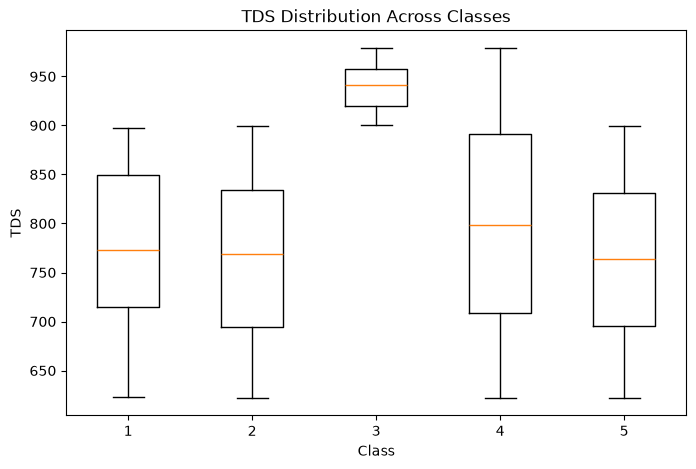

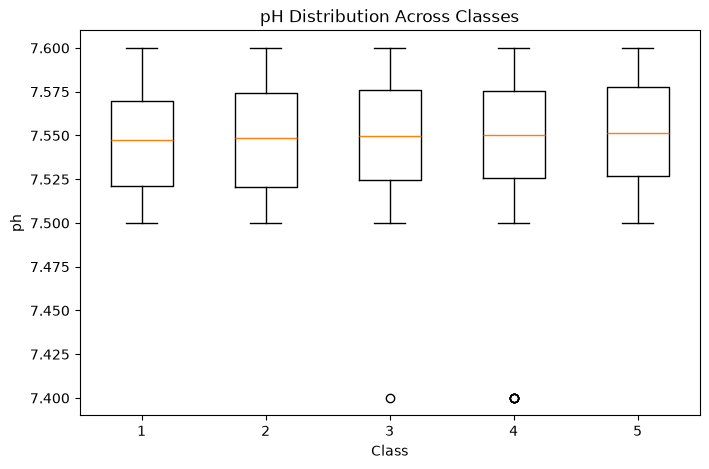

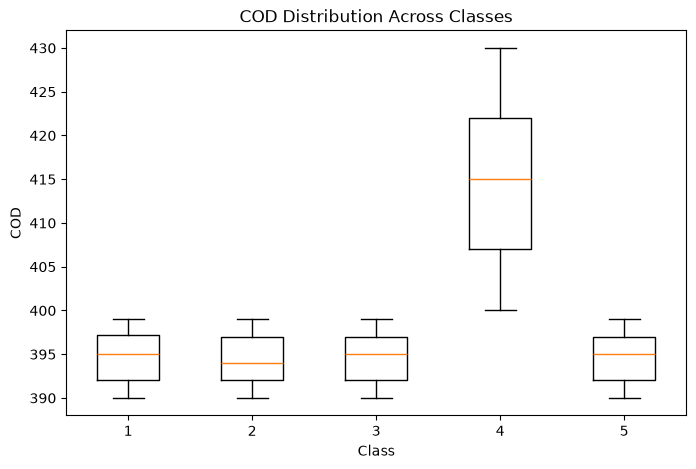

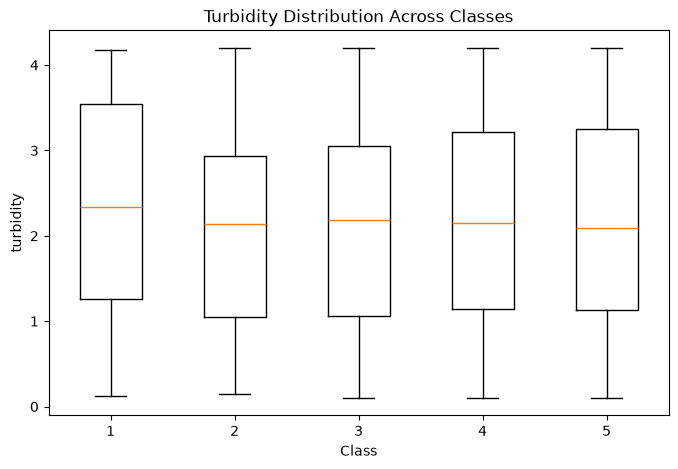

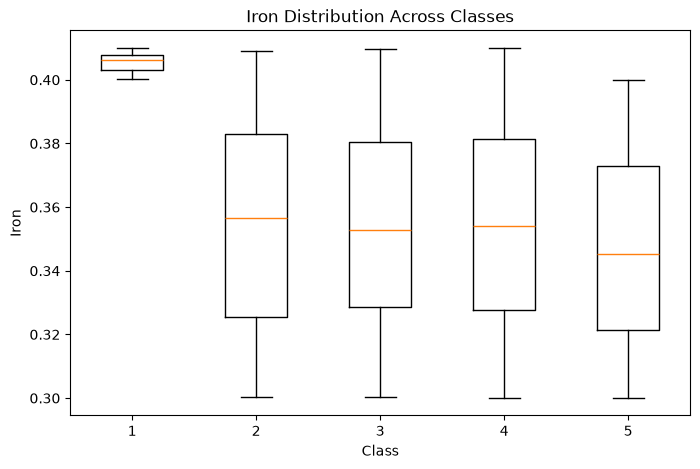

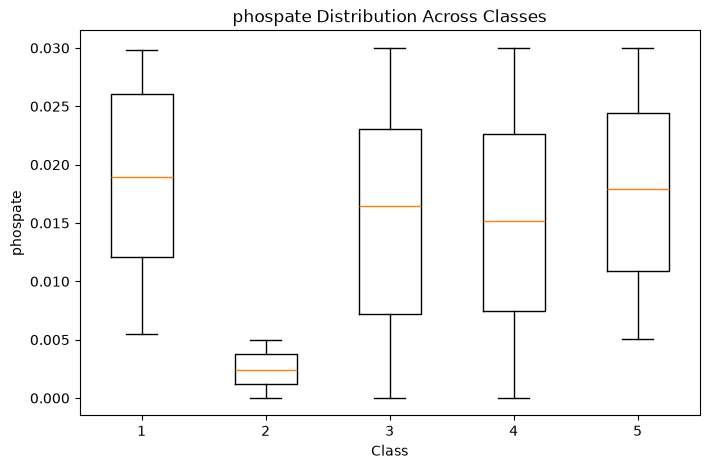

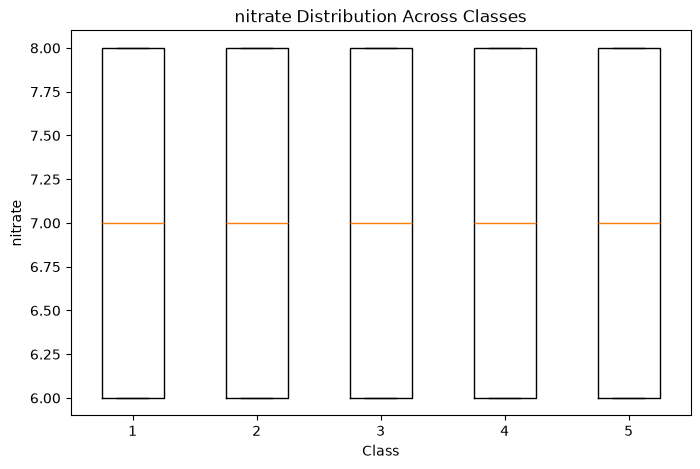

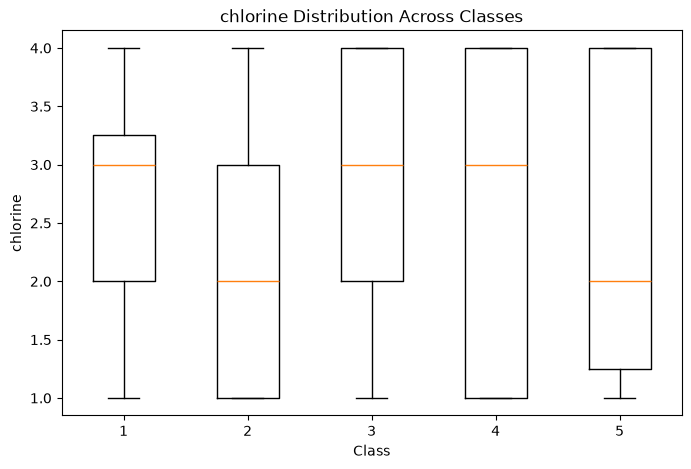

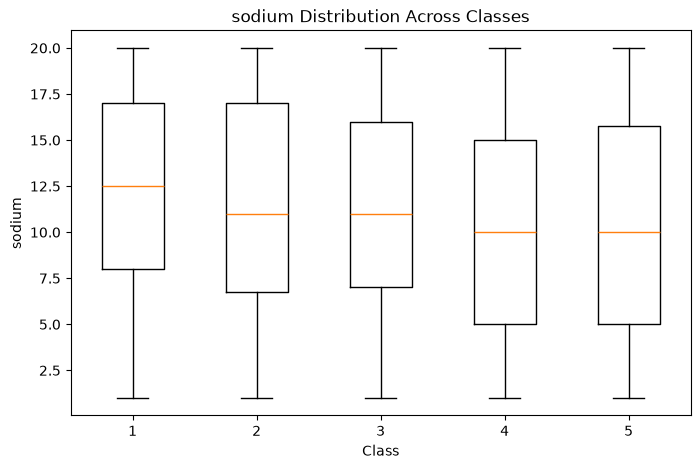

In [25]:
# --------TDS---------------
plt.figure(figsize=(8, 5))

plt.boxplot(
    tds_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("TDS")
plt.title("TDS Distribution Across Classes")
plt.savefig("../distribution_plots/tds_distribution.png")
plt.show()

# ---------ph------------
plt.figure(figsize=(8, 5))

plt.boxplot(
    ph_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("ph")
plt.title("pH Distribution Across Classes")
plt.savefig("../distribution_plots/ph_distribution.png")
plt.show()
#---------COD---------------
plt.figure(figsize=(8, 5))

plt.boxplot(
    cod_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("COD")
plt.title("COD Distribution Across Classes")
plt.savefig("../distribution_plots/cod_distribution.png")
plt.show()
# turbidity 
plt.figure(figsize=(8, 5))

plt.boxplot(
    turbidity_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("turbidity")
plt.title("Turbidity Distribution Across Classes")
plt.savefig("../distribution_plots/turbidity_distribution.png")
plt.show()
# ---------iron---------------

plt.figure(figsize=(8, 5))

plt.boxplot(
    iron_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("Iron")
plt.title("Iron Distribution Across Classes")
plt.savefig("../distribution_plots/iron_distribution.png")
plt.show()

# ---------phos------------------
plt.figure(figsize=(8, 5))

plt.boxplot(
    phospate_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("phospate")
plt.title("phospate Distribution Across Classes")
plt.savefig("../distribution_plots/phosphate_distribution.png")
plt.show()
# nitrate
plt.figure(figsize=(8, 5))

plt.boxplot(
    nitrate_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("nitrate")
plt.title("nitrate Distribution Across Classes")
plt.savefig("../distribution_plots/nitrate_distribution.png")
plt.show()

# chlorine
plt.figure(figsize=(8, 5))

plt.boxplot(
    chlorine_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("chlorine")
plt.title("chlorine Distribution Across Classes")
plt.savefig("../distribution_plots/chlorine_distribution.png")
plt.show()

#sodium
plt.figure(figsize=(8, 5))

plt.boxplot(
    sodium_by_class,
    label=[f"Class {c}" for c in range(5)]
)

plt.xlabel("Class")
plt.ylabel("sodium")
plt.title("sodium Distribution Across Classes")
plt.savefig("../distribution_plots/sodium_distribution.png")
plt.show()


### Kruskal Wallis test 

In [28]:
from scipy.stats import kruskal


results = []

for f in features :
    groups = [
        df[df["Class"] == c][f]
        for c in range(5)
    ]
    H,p = kruskal(*groups)
    results.append(
        {
            "Feature" : f,
            "H-stat" : H, 
            "p-values" : p            
        }  
    )
kruskal_results = pd.DataFrame(results)
print(kruskal_results)


     Feature       H-stat       p-values
0         pH     4.006418   4.051380e-01
1        TDS   618.453068  1.571453e-132
2  Turbidity     3.106520   5.401604e-01
3   Phospate   427.423216   3.296730e-91
4    Nitrate     1.737173   7.839545e-01
5       Iron   214.953823   2.284061e-45
6  COD(mg/L)  2841.277537   0.000000e+00
7   Chlorine     6.198179   1.848289e-01
8     Sodium    15.536238   3.708986e-03


In [30]:
from statsmodels.stats.multitest import multipletests

kruskal_results["p-adjusted"] = multipletests(
    kruskal_results["p-values"],
    method="fdr_bh"
)[1]

kruskal_results["significant"] = (
    kruskal_results["p-adjusted"] < 0.05
)

print(kruskal_results)


     Feature       H-stat       p-values     p-adjusted  significant
0         pH     4.006418   4.051380e-01   5.208917e-01        False
1        TDS   618.453068  1.571453e-132  7.071540e-132         True
2  Turbidity     3.106520   5.401604e-01   6.076805e-01        False
3   Phospate   427.423216   3.296730e-91   9.890191e-91         True
4    Nitrate     1.737173   7.839545e-01   7.839545e-01        False
5       Iron   214.953823   2.284061e-45   5.139136e-45         True
6  COD(mg/L)  2841.277537   0.000000e+00   0.000000e+00         True
7   Chlorine     6.198179   1.848289e-01   2.772434e-01        False
8     Sodium    15.536238   3.708986e-03   6.676176e-03         True


### post hoc dunn's test

In [ ]:
import scikit_posthocs as sp
import pandas as pd

significant_features = [
    "TDS",
    "Phospate",
    "Iron",
    "COD(mg/L)",
    "Sodium"
]

dunn_results = {}

for feature in significant_features:

    result = sp.posthoc_dunn(
        df,
        val_col=feature,
        group_col="Class",
        p_adjust="holm"
    )

    dunn_results[feature] = result

    print(f"\n{'='*50}")
    print(f"{feature}")
    print(f"{'='*50}")
    print(result)



TDS
              0             1              2              3              4
0  1.000000e+00  1.000000e+00   2.500251e-34   6.260405e-02   1.000000e+00
1  1.000000e+00  1.000000e+00   9.900248e-67   4.133055e-05   1.000000e+00
2  2.500251e-34  9.900248e-67   1.000000e+00  1.248901e-102  3.555194e-127
3  6.260405e-02  4.133055e-05  1.248901e-102   1.000000e+00   1.164066e-17
4  1.000000e+00  1.000000e+00  3.555194e-127   1.164066e-17   1.000000e+00

Phospate
              0             1             2             3             4
0  1.000000e+00  3.464709e-38  2.064701e-02  3.712964e-03  8.375379e-01
1  3.464709e-38  1.000000e+00  7.715319e-51  2.547401e-74  2.636084e-91
2  2.064701e-02  7.715319e-51  1.000000e+00  8.375379e-01  1.306356e-03
3  3.712964e-03  2.547401e-74  8.375379e-01  1.000000e+00  1.338453e-12
4  8.375379e-01  2.636084e-91  1.306356e-03  1.338453e-12  1.000000e+00

Iron
              0             1             2             3             4
0  1.000000e+00  1.115839

In [ ]:
# Number of classes
k = df["Class"].nunique()

# Total number of observations
N = len(df)

# Calculate Kruskal-Wallis effect size: epsilon squared
kruskal_results["epsilon_squared"] = (
    (kruskal_results["H-stat"] - k + 1) / (N - k)
)

# Avoid negative effect sizes caused by very small H statistics
kruskal_results["epsilon_squared"] = (
    kruskal_results["epsilon_squared"].clip(lower=0)
)

print(kruskal_results)


     Feature       H-stat       p-values     p-adjusted  significant  \
0         pH     4.006418   4.051380e-01   5.208917e-01        False   
1        TDS   618.453068  1.571453e-132  7.071540e-132         True   
2  Turbidity     3.106520   5.401604e-01   6.076805e-01        False   
3   Phospate   427.423216   3.296730e-91   9.890191e-91         True   
4    Nitrate     1.737173   7.839545e-01   7.839545e-01        False   
5       Iron   214.953823   2.284061e-45   5.139136e-45         True   
6  COD(mg/L)  2841.277537   0.000000e+00   0.000000e+00         True   
7   Chlorine     6.198179   1.848289e-01   2.772434e-01        False   
8     Sodium    15.536238   3.708986e-03   6.676176e-03         True   

   epsilon_squared  
0         0.000001  
1         0.120599  
2         0.000000  
3         0.083106  
4         0.000000  
5         0.041404  
6         0.556875  
7         0.000431  
8         0.002264  


### cliffs delta

In [ ]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    greater = np.sum(x[:, None] > y[None, :])
    less = np.sum(x[:, None] < y[None, :])

    return (greater - less) / (len(x) * len(y))


features_to_test = [
    "Iron",
    "Phospate",
    "TDS",
    "COD(mg/L)"
]

classes = sorted(df["Class"].unique())

cliffs_results = {}

for feature in features_to_test:

    delta_matrix = pd.DataFrame(
        np.nan,
        index=classes,
        columns=classes
    )

    for i in classes:
        for j in classes:

            if i == j:
                delta_matrix.loc[i, j] = 0
                continue

            x = df[df["Class"] == i][feature]
            y = df[df["Class"] == j][feature]

            delta_matrix.loc[i, j] = cliffs_delta(x, y)

    cliffs_results[feature] = delta_matrix

    print("\n" + "=" * 50)
    print(feature)
    print("=" * 50)
    print(delta_matrix)



Iron
          0         1         2         3         4
0  0.000000  0.942791  0.927514  0.920908  1.000000
1 -0.942791  0.000000  0.019943  0.014773  0.141189
2 -0.927514 -0.019943  0.000000 -0.002731  0.122386
3 -0.920908 -0.014773  0.002731  0.000000  0.124267
4 -1.000000 -0.141189 -0.122386 -0.124267  0.000000

Phospate
          0         1         2         3         4
0  0.000000  1.000000  0.200527  0.228032  0.071054
1 -1.000000  0.000000 -0.826034 -0.839868 -1.000000
2 -0.200527  0.826034  0.000000  0.020850 -0.143113
3 -0.228032  0.839868 -0.020850  0.000000 -0.170713
4 -0.071054  1.000000  0.143113  0.170713  0.000000

TDS
          0         1         2         3         4
0  0.000000  0.042493 -1.000000 -0.164094  0.045523
1 -0.042493  0.000000 -1.000000 -0.201494 -0.000562
2  1.000000  1.000000  0.000000  0.775277  1.000000
3  0.164094  0.201494 -0.775277  0.000000  0.201491
4 -0.045523  0.000562 -1.000000 -0.201491  0.000000

COD(mg/L)
          0         1         2 

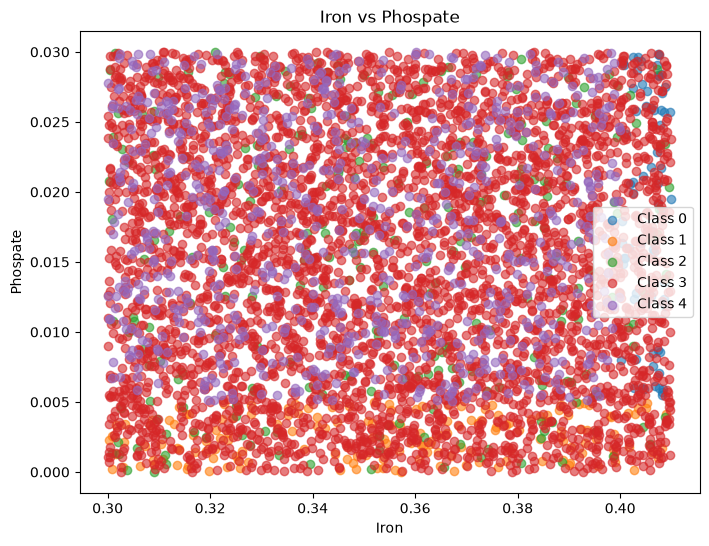

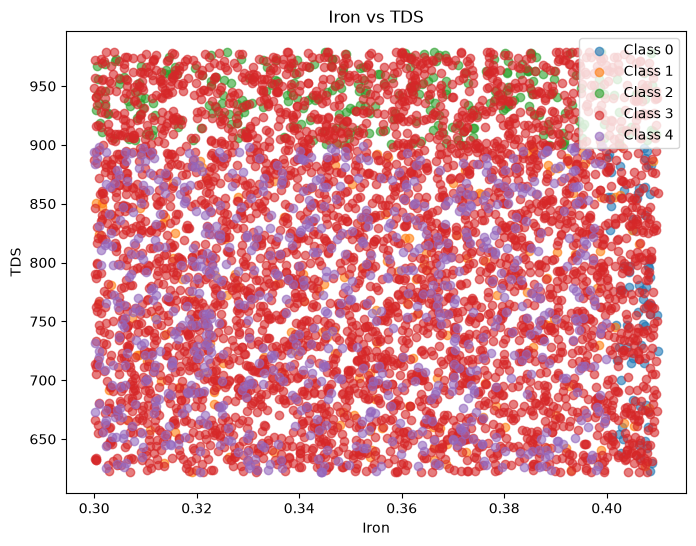

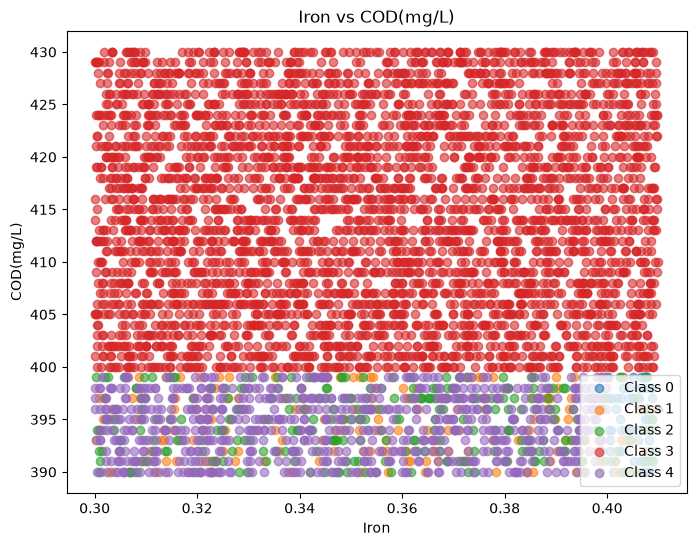

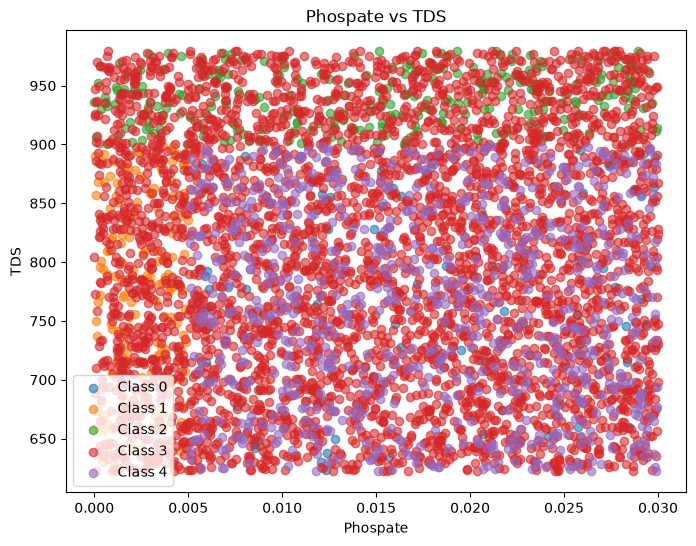

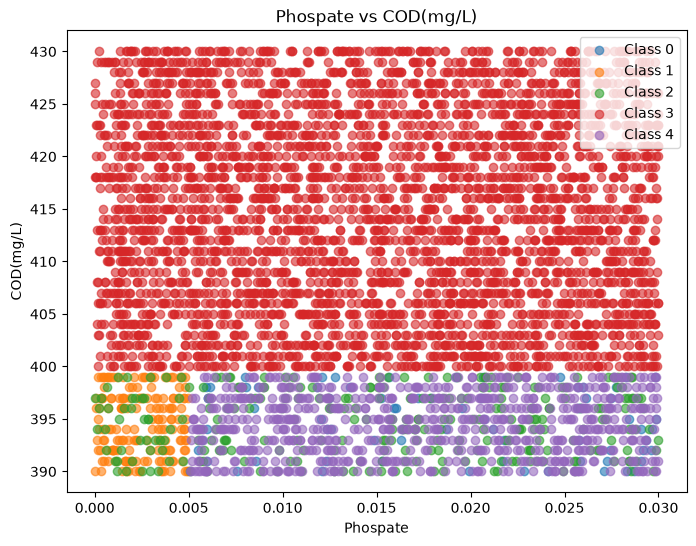

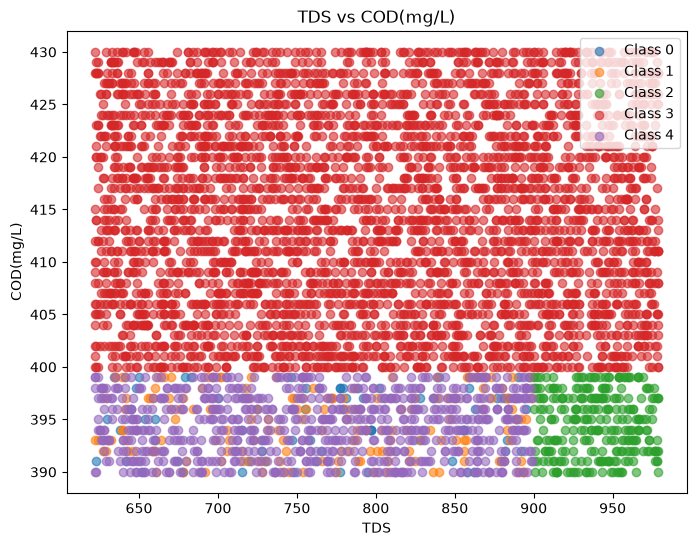

In [39]:
import itertools
import matplotlib.pyplot as plt
import re
from pathlib import Path

output_dir = Path("../signature_plots")
output_dir.mkdir(parents=True, exist_ok=True)

signature_features = [
    "Iron",
    "Phospate",
    "TDS",
    "COD(mg/L)"
]

pairs = list(itertools.combinations(signature_features, 2))

for x_feature, y_feature in pairs:
    plt.figure(figsize=(8, 6))

    for c in sorted(df["Class"].unique()):
        class_data = df[df["Class"] == c]

        plt.scatter(
            class_data[x_feature],
            class_data[y_feature],
            label=f"Class {c}",
            alpha=0.6
        )

    plt.xlabel(x_feature)
    plt.ylabel(y_feature)
    plt.title(f"{x_feature} vs {y_feature}")
    plt.legend()

    file_name = re.sub(
        r'[<>:"/\\|?*]+',
        "_",
        f"{x_feature}_vs_{y_feature}"
    )

    plt.savefig(
        output_dir / f"{file_name}.png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


### Desicion Tree Classifier

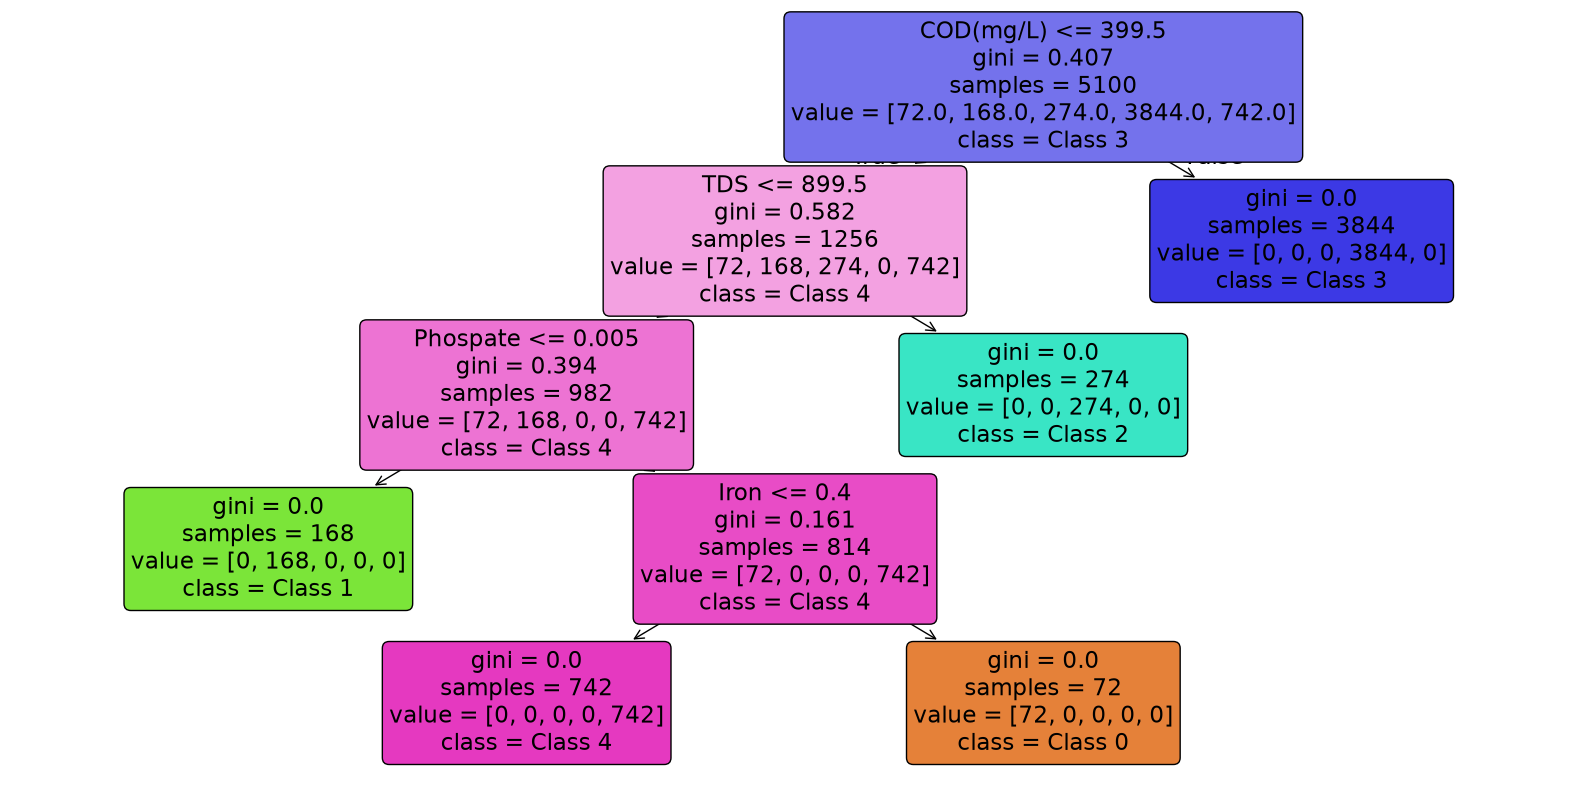

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

signature_features = [
    "Iron",
    "Phospate",
    "TDS",
    "COD(mg/L)"
]

X = df[signature_features]
y = df["Class"]

tree = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

tree.fit(X, y)

plt.figure(figsize=(20, 10))

plot_tree(
    tree,
    feature_names=signature_features,
    class_names=[f"Class {c}" for c in sorted(y.unique())],
    filled=True,
    rounded=True
)

plt.show()


#### verification

In [ ]:

def classify_water(row):

    if row["COD(mg/L)"] > 399.5:
        return 3

    elif row["TDS"] > 899.5:
        return 2

    elif row["Phospate"] <= 0.005:
        return 1

    elif row["Iron"] > 0.4:
        return 0

    else:
        return 4


# Apply our reconstructed rule
df["predicted_class"] = df.apply(classify_water, axis=1)


# Compare with original labels
df["correct"] = df["Class"] == df["predicted_class"]

accuracy = df["correct"].mean()
mismatches = (~df["correct"]).sum()

print(f"Accuracy: {accuracy:.4%}")
print(f"Mismatches: {mismatches}")
mismatch_df = df[df["Class"] != df["predicted_class"]]

print(mismatch_df[
    ["Class", "predicted_class",
     "COD(mg/L)", "TDS", "Phospate", "Iron"]
])


Accuracy: 100.0000%
Mismatches: 0
Empty DataFrame
Columns: [Class, predicted_class, COD(mg/L), TDS, Phospate, Iron]
Index: []


## Conclusion 

we found class as 

Class 0 → Ferric Profile 

Class 1 → Phosphate-Depleted Profile

Class 2 → Dissolved-Solids Profile

Class 3 → Oxygen-Demand Profile

Class 4 → Neutral Baseline Profile

